# Model residuals plot 
Residual distributions from the final trained model applied to the full spatial domain are stratified by National Land Cover Database (NLCD) vegetation class and by fire.

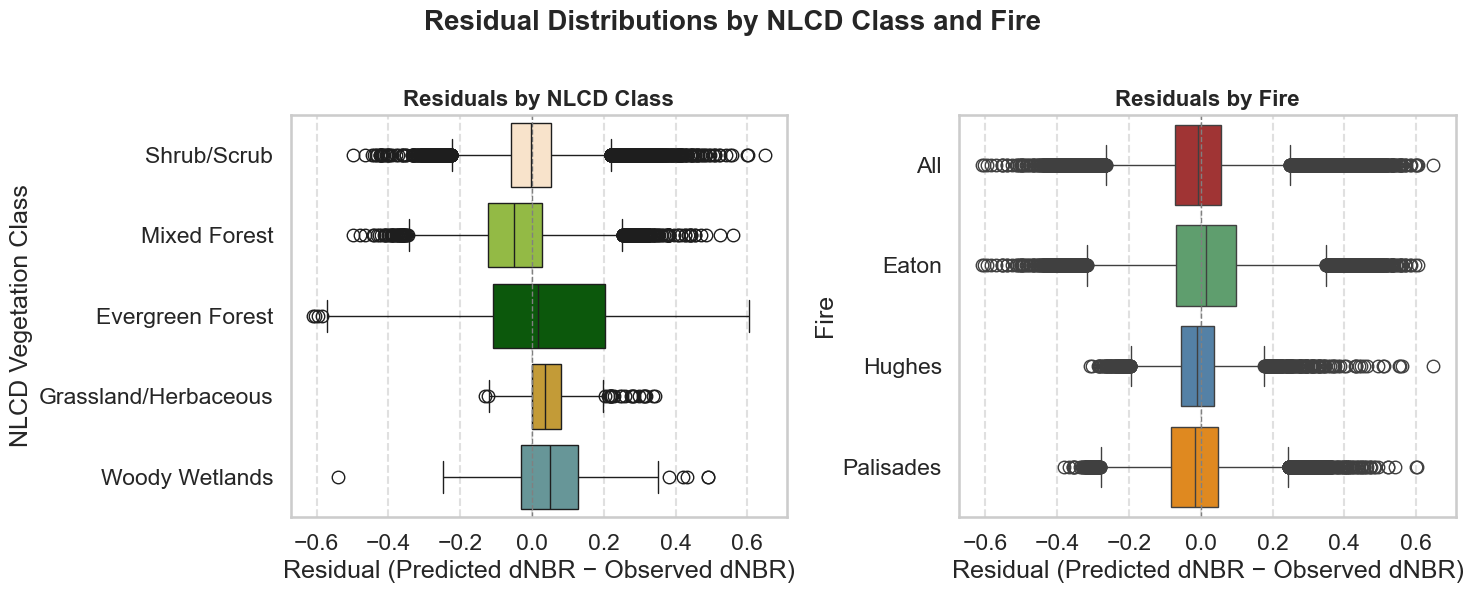

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# -----------------------------
# Style 
# -----------------------------
mpl.rcParams["font.family"] = "Arial"
sns.set_theme(style="whitegrid", context="talk")  # same intent as sns.set(style="whitegrid", context="talk")

# -----------------------------
# 1. Load full-scene predictions
# -----------------------------
df = pd.read_parquet("/Users/megan/Desktop/AGUAdvances_review/Model_files/reduced_rf_predictions_20251023.parquet")

# -----------------------------
# 2. Map NLCD codes to class names
# -----------------------------
nlcd_classes = {
    11: 'Open Water', 12: 'Perennial Ice/Snow',
    21: 'Developed, Open Space', 22: 'Developed, Low Intensity',
    23: 'Developed, Medium Intensity', 24: 'Developed, High Intensity',
    31: 'Barren Land', 41: 'Deciduous Forest', 42: 'Evergreen Forest',
    43: 'Mixed Forest', 52: 'Shrub/Scrub', 71: 'Grassland/Herbaceous',
    81: 'Pasture/Hay', 82: 'Cultivated Crops',
    90: 'Woody Wetlands', 95: 'Emergent Herbaceous Wetlands'
}
df["NLCD_Class"] = df["NLCD"].map(nlcd_classes)

# -----------------------------
# 3. Filter to NLCD classes (≥30 pixels)
# -----------------------------
min_pixels = 30
valid_classes = df["NLCD_Class"].value_counts()[lambda x: x >= min_pixels].index.tolist()
df_plot = df[df["NLCD_Class"].isin(valid_classes)].copy()

# -----------------------------
# 4. Add "All" residuals for fire-wise plot
# -----------------------------
df_fire = df_plot[["Fire", "Residual_reduced"]].dropna().copy()
df_all = df_fire.copy()
df_all["Fire"] = "All"
df_fire_combined = pd.concat([df_fire, df_all], ignore_index=True)

# -----------------------------
# 5. Set palettes and order
# -----------------------------
fire_palette = {
    "Eaton": "g",
    "Hughes": "steelblue",
    "Palisades": "darkorange",
    "All": "firebrick"
}
fire_order = ["All", "Eaton", "Hughes", "Palisades"]

nlcd_palette = {
    "Shrub/Scrub": "bisque",
    "Mixed Forest": "yellowgreen",
    "Evergreen Forest": "darkgreen",
    "Grassland/Herbaceous": "goldenrod",
    "Woody Wetlands": "cadetblue",
    "Emergent Herbaceous Wetlands": "mediumaquamarine"
}
palette_subset = {k: v for k, v in nlcd_palette.items() if k in valid_classes}

# keep NLCD order consistent with palette order (instead of sorted())
nlcd_order = [k for k in nlcd_palette.keys() if k in valid_classes]

# -----------------------------
# 6. Create side-by-side plots
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

# --- Left: Residuals by NLCD class ---
sns.boxplot(
    data=df_plot,
    x="Residual_reduced",
    y="NLCD_Class",
    hue="NLCD_Class",             
    order=nlcd_order,
    orient="h",
    palette=palette_subset,
    showfliers=True,
    legend=False,                 
    ax=axs[0]
)
axs[0].axvline(0, color="gray", linestyle="--", linewidth=1)
axs[0].set_title("Residuals by NLCD Class", fontweight="bold", fontsize=16)
axs[0].set_xlabel("Residual (Predicted dNBR − Observed dNBR)")
axs[0].set_ylabel("NLCD Vegetation Class")
axs[0].grid(True, axis="x", linestyle="--", alpha=0.6)

# --- Right: Residuals by Fire (+ All) ---
sns.boxplot(
    data=df_fire_combined,
    x="Residual_reduced",
    y="Fire",
    hue="Fire",                  
    order=fire_order,
    orient="h",
    palette=fire_palette,
    showfliers=True,
    legend=False,                 
    ax=axs[1]
)
axs[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axs[1].set_title("Residuals by Fire", fontweight="bold", fontsize=16)
axs[1].set_xlabel("Residual (Predicted dNBR − Observed dNBR)")
axs[1].set_ylabel("Fire")
axs[1].grid(True, axis="x", linestyle="--", alpha=0.6)

# -----------------------------
# 7. Save and show
# -----------------------------
plt.suptitle("Residual Distributions by NLCD Class and Fire", fontsize=20, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(
    "/Users/megan/Desktop/residuals_by_nlcd_and_fire_reducedmodel.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()